In [2]:
import pandas as pd
import numpy as np

In [3]:
class_df = pd.read_csv("clean_crop_contribution_data/aggregated_data/kmeans_classes/rice_classified.csv")

In [4]:
features_df = pd.read_csv('engineered_climate_features_slight_correlation.csv')

In [5]:
class_df["location"] = class_df["State"] + "_" + class_df["District"]
merged_df = class_df.merge(features_df, on="location", how="inner")
print(merged_df.shape)
merged_df

(720, 42)


,State,District,Median,Max,Yield_Class,location,tp_kharif_mean,tp_kharif_std,e_kharif_mean,e_kharif_std,...,GDD_rabi,heat_months_30C,heat_months_35C,humidity_variability,swvl1_amplitude,swvl1_stability,soil_moisture_seasonality,cvh,water_retention_index,humidity_stress_index
0,A & N Islands,Nicobars,1.730,5.77,Medium,A & N Islands_Nicobars,0.212075,0.009158,-0.144988,0.012498,...,67.030034,0,0,0.403557,0.000005,9.164305,-3.721546e-07,0.000000,0.357962,8.448173
1,A & N Islands,North And Middle Andaman,2.185,3.16,High,A & N Islands_North And Middle Andaman,0.337536,0.009329,-0.137305,0.010667,...,66.739761,0,0,1.009721,0.082650,0.663154,2.567770e-02,0.097324,0.171858,3.615982
2,A & N Islands,South Andamans,2.435,3.04,High,A & N Islands_South Andamans,0.311476,0.022785,-0.144685,0.010310,...,67.797892,0,0,0.846505,0.010900,0.650601,3.163555e-03,0.009017,0.277637,4.320013
3,Andhra Pradesh,Alluri Sitharama Raju,2.990,2.99,High,Andhra Pradesh_Alluri Sitharama Raju,0.312446,0.044864,-0.094966,0.003045,...,50.285603,0,0,1.968619,0.238318,0.611573,1.239291e-01,0.737434,-0.059075,2.707588
4,Andhra Pradesh,Anakapalli,3.140,3.14,High,Andhra Pradesh_Anakapalli,0.228586,0.028609,-0.107531,0.002641,...,56.039035,1,0,0.958582,0.191011,0.669571,9.344429e-02,0.403020,-0.069854,4.945039
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
715,West Bengal,Murshidabad,2.910,3.29,High,West Bengal_Murshidabad,0.275707,0.021696,-0.112844,0.002819,...,46.448733,2,0,1.888184,0.212852,0.553644,1.418102e-01,0.333241,-0.090637,2.708996
716,West Bengal,Nadia,2.920,3.34,High,West Bengal_Nadia,0.278344,0.025523,-0.114582,0.002691,...,47.466119,2,0,1.631112,0.208986,0.542105,1.389152e-01,0.082477,-0.103035,2.954232
717,West Bengal,Paschim Bardhaman,3.090,3.39,High,West Bengal_Paschim Bardhaman,0.253455,0.021283,-0.109788,0.001778,...,44.891160,3,0,2.463836,0.218843,0.580043,1.424418e-01,0.344329,-0.068096,2.365677
718,West Bengal,Purba Bardhaman,3.070,3.59,High,West Bengal_Purba Bardhaman,0.270052,0.023807,-0.110861,0.002242,...,47.207326,3,0,1.842454,0.212822,0.554204,1.423393e-01,0.354676,-0.079435,2.812093


In [6]:
set(class_df["location"]) - set(features_df["location"])

{'Nagaland_Dimapur', 'Nagaland_Niuland', 'Puducherry_Mahe', 'Puducherry_Yanam'}

In [7]:
print(merged_df["Yield_Class"].value_counts())
print(merged_df["Yield_Class"].value_counts(normalize=True))

Yield_Class
High      349
Medium    305
Low        66
Name: count, dtype: int64
Yield_Class
High      0.484722
Medium    0.423611
Low       0.091667
Name: proportion, dtype: float64


In [8]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
merged_df["Yield_Class_Encoded"] = le.fit_transform(merged_df["Yield_Class"])

print("\nEncoding mapping:")
print(dict(zip(le.classes_, le.transform(le.classes_))))


Encoding mapping:
{'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}


In [9]:
drop_cols = ["State", "District", "location", "Median", "Max", "Yield_Class"]

X = merged_df.drop(columns=drop_cols + ["Yield_Class_Encoded"])
y = merged_df["Yield_Class_Encoded"]

print("\nFeature shape:", X.shape)


Feature shape: (720, 36)


In [10]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y)
class_weight_dict = dict(zip(classes, weights))
sample_weights = y.map(class_weight_dict)

In [11]:
from sklearn.model_selection import StratifiedKFold

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_metrics = []
shap_importance_list = []

In [12]:
from sklearn.metrics import accuracy_score, f1_score
from sklearn.ensemble import RandomForestClassifier
import shap

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):

    print(f"\n====================")
    print(f"Fold {fold+1}")
    print(f"====================")

    X_train = X.iloc[train_idx]
    X_val   = X.iloc[val_idx]
    y_train = y.iloc[train_idx]
    y_val   = y.iloc[val_idx]
    w_train = sample_weights.iloc[train_idx]

    model = RandomForestClassifier(
        n_estimators=400,
        max_depth=5,
        random_state=42,
        class_weight="balanced"   # RF has native class_weight support
    )

    model.fit(X_train, y_train, sample_weight=w_train)

    # ---------------- Metrics ----------------
    preds = model.predict(X_val)
    acc = accuracy_score(y_val, preds)
    f1  = f1_score(y_val, preds, average="weighted")
    fold_metrics.append((acc, f1))

    print("Accuracy:", acc)
    print("F1:", f1)

    # ---------------- SHAP ----------------
    explainer  = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_val)

    if isinstance(shap_values, list):
        shap_vals = np.mean([np.abs(sv) for sv in shap_values], axis=0)
    elif shap_values.ndim == 3:
        shap_vals = np.abs(shap_values).mean(axis=2)
    else:
        shap_vals = np.abs(shap_values)

    shap_mean = shap_vals.mean(axis=0)
    shap_importance_list.append(shap_mean)


Fold 1
Accuracy: 0.6875
F1: 0.6965548975717246

Fold 2
Accuracy: 0.7777777777777778
F1: 0.7836467419800753

Fold 3
Accuracy: 0.7013888888888888
F1: 0.7050224067270534

Fold 4
Accuracy: 0.7083333333333334
F1: 0.7220050629141538

Fold 5
Accuracy: 0.7152777777777778
F1: 0.7157325102880658


In [13]:
fold_metrics = np.array(fold_metrics)

print("\n====================")
print("FINAL CV METRICS")
print("====================")
print("Accuracy mean:", fold_metrics[:,0].mean())
print("Accuracy std:",  fold_metrics[:,0].std())
print("F1 mean:",       fold_metrics[:,1].mean())
print("F1 std:",        fold_metrics[:,1].std())


FINAL CV METRICS
Accuracy mean: 0.7180555555555556
Accuracy std: 0.03124228299778332
F1 mean: 0.7245923238962145
F1 std: 0.030795108198195646


In [14]:
shap_importance = np.mean(shap_importance_list, axis=0)

print("shap_importance shape:", shap_importance.shape)
print("Number of features:", len(X.columns))

if shap_importance.ndim > 1:
    shap_importance = np.abs(shap_importance).mean(axis=tuple(range(shap_importance.ndim - 1)))

print("shap_importance shape after fix:", shap_importance.shape)

importance_df = pd.DataFrame({
    "feature":    X.columns,
    "importance": shap_importance
}).sort_values("importance", ascending=False)

print("\nAll features sorted according to SHAP importance:")
print(importance_df)

shap_importance shape: (36,)
Number of features: 36
shap_importance shape after fix: (36,)

All features sorted according to SHAP importance:
                      feature  importance
29       humidity_variability    0.050352
16                e_zaid_mean    0.046502
0              tp_kharif_mean    0.027369
18             swvl1_zaid_std    0.023934
15               tp_zaid_mean    0.021999
6    soil_air_diff_kharif_std    0.020665
21         tp_kharif_fraction    0.018944
35      humidity_stress_index    0.017731
14     runoff_ratio_rabi_mean    0.017527
3                e_kharif_std    0.016756
2               e_kharif_mean    0.016025
7    runoff_ratio_kharif_mean    0.015647
4           swvl1_kharif_mean    0.015200
22              t2m_amplitude    0.013393
25                 GDD_kharif    0.012355
17                 e_zaid_std    0.012158
32  soil_moisture_seasonality    0.011583
26                   GDD_rabi    0.011135
20     runoff_ratio_zaid_mean    0.011040
5   soil_air_diff_

<Figure size 800x1000 with 0 Axes>

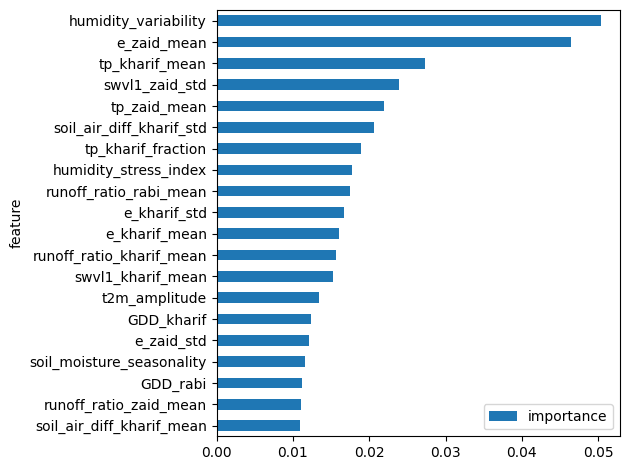

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 10))
importance_df.head(20).plot(x="feature", y="importance", kind="barh")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()